In [3]:
import numpy as np
import tensorflow as tf
import os
from pathlib import Path
import matplotlib.pyplot as plt

from tensorflow.keras.utils import (
    image_dataset_from_directory,
    load_img,
    img_to_array
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    Rescaling
)

from tensorflow.keras.applications import VGG16

### Loading the data

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 2

dataset_path = r"d:\DEEP_LEARNING\GarbageDataset\Garbage classification\Garbage classification"
#ds_path = "DATASETS/marvel/train"

train_ds, val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="both",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Using 505 files for validation.


In [ ]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(images.dtype)
    print(labels)

NameError: name 'train_ds' is not defined

In [5]:
class_names = train_ds.class_names

print("\nClasses Found:")
print(class_names)


Classes Found:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### Data Augmentation

In [6]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.2),
    RandomZoom(0.2)
])

### Load pretrained VGG16

In [7]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


# Building the Final Model

In [8]:
model = Sequential([
    data_augmentation,

    Rescaling(1./255),

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),

    Dropout(0.3),

    Dense(len(class_names), activation="softmax")
])


### Compile the model

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Train the model

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
)

Epoch 1/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 405s 399ms/step - accuracy: 0.4120 - loss: 1.4357 - val_accuracy: 0.5525 - val_loss: 1.1550
Epoch 2/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 401s 397ms/step - accuracy: 0.5460 - loss: 1.1240 - val_accuracy: 0.6000 - val_loss: 1.0568
Epoch 3/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 420s 415ms/step - accuracy: 0.5772 - loss: 1.0387 - val_accuracy: 0.6277 - val_loss: 1.0045
Epoch 4/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 437s 432ms/step - accuracy: 0.6152 - loss: 0.9656 - val_accuracy: 0.6673 - val_loss: 0.9247
Epoch 5/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 393s 389ms/step - accuracy: 0.6291 - loss: 0.9377 - val_accuracy: 0.7149 - val_loss: 0.8759
Epoch 6/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 393s 388ms/step - accuracy: 0.6439 - loss: 0.8942 - val_accuracy: 0.7208 - val_loss: 0.8561
Epoch 7/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 399s 395ms/step - accuracy: 0.6701 - loss: 0.8670 - val_accuracy: 0.7129 - val_loss: 0.8481
Epoch 8/10
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 398s 393ms/step - ac

In [11]:
print(history.history["loss"])
print(history.history["accuracy"])

[1.4357465505599976, 1.1239649057388306, 1.038681983947754, 0.9655526876449585, 0.9376882314682007, 0.8941659331321716, 0.8669717311859131, 0.8428080081939697, 0.8095072507858276, 0.8004704117774963]
[0.4119683504104614, 0.5459940433502197, 0.577151358127594, 0.6152324676513672, 0.6290801167488098, 0.6439169049263, 0.670128583908081, 0.6755687594413757, 0.694856584072113, 0.6983184814453125]


### Testing on new Images

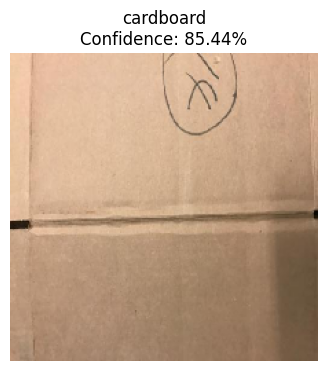

cardboard1.jpg -> cardboard (85.44%)


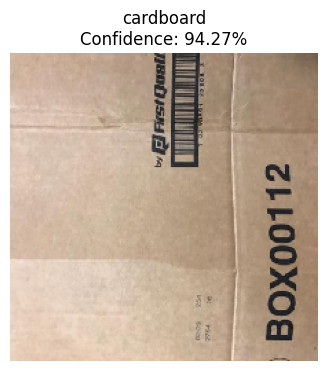

cardboard10.jpg -> cardboard (94.27%)


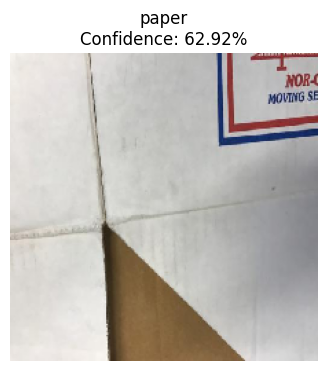

cardboard100.jpg -> paper (62.92%)


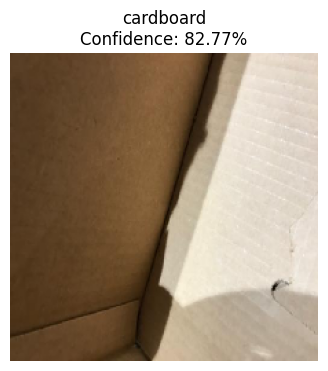

cardboard101.jpg -> cardboard (82.77%)


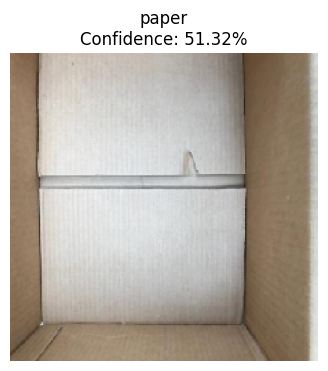

cardboard102.jpg -> paper (51.32%)


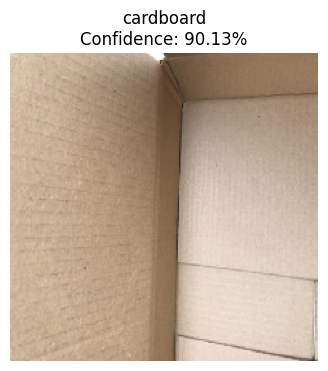

cardboard103.jpg -> cardboard (90.13%)


In [12]:
sample_images = list(Path(dataset_path).rglob("*.jpg"))[:6]

for image_path in sample_images:
    img = load_img(
        image_path,
        target_size=(224,224)
    )

    img_array = img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = model.predict(
        img_array,
        verbose=0
    )

    predicted_class = class_names[
        np.argmax(prediction)
    ]

    confidence = np.max(prediction)

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"{predicted_class}\nConfidence: {confidence*100:.2f}%"
    )

    plt.show()

    print(
        f"{image_path.name} -> {predicted_class} ({confidence*100:.2f}%)"
    )
